# 📊 Google Play Store Data Analysis

## Internship Project

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib

**Dataset Used:**
- Play Store Data.csv
- User Reviews.csv

**Objective:**
Analyze the Google Play Store dataset by performing data cleaning, transformation, filtering, and visualization based on the internship requirements.

## 1. Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px 

from datetime import datetime
import pytz
from zoneinfo import ZoneInfo

## 2. Load Datasets

In [2]:
df = pd.read_csv("Play Store Data.csv")
reviews_df = pd.read_csv("User Reviews.csv")  

## 3. Data Cleaning & Preprocessing

In [3]:
df = df.dropna(subset=["Rating"])

In [4]:
df["Size_clean"] = df["Size"]

In [5]:
df["Size_clean"] = df["Size_clean"].replace("Varies with device", np.nan)

In [6]:
df["Size_clean"].isnull().sum()

np.int64(1637)

In [7]:
df["Size_clean"] = df["Size_clean"].str.replace("M", "", regex=False)

In [8]:
df["Size_clean"] = df["Size_clean"].replace(
    r'([0-9.]+)k',
    lambda x: str(float(x.group(1)) / 1000),
    regex=True
)

In [9]:
df["Size_clean"] = df["Size"]

In [10]:
df["Size_clean"] = df["Size_clean"].replace("Varies with device", np.nan)

In [11]:
df["Size_clean"] = df["Size_clean"].str.replace("M", "", regex=False)

In [12]:
mask = df["Size_clean"].str.contains("k", na=False)

df.loc[mask, "Size_clean"] = df.loc[mask, "Size_clean"].str.replace("k", "", regex=False).astype(float) / 1000

In [13]:
df["Size_clean"] = pd.to_numeric(df["Size_clean"], errors="coerce")

In [14]:
df["Installs_clean"] = df["Installs"]

In [15]:
df["Installs_clean"] = df["Installs_clean"].str.replace("+", "", regex=False)

In [16]:
df["Installs_clean"] = df["Installs_clean"].str.replace(",", "", regex=False)

In [17]:
df[df["Installs_clean"] == "Free"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_clean,Installs_clean
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN,NaN,Free


In [18]:
df = df[df["Installs_clean"] != "Free"]



In [19]:
df["Installs_clean"] = df["Installs_clean"].astype(int)

In [20]:
df["Installs_clean"].dtype

dtype('int64')

In [21]:
df[pd.to_numeric(df["Reviews"], errors="coerce").isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_clean,Installs_clean


In [22]:
df[pd.to_numeric(df["Reviews"], errors="coerce").isna()][["App", "Reviews"]]

,App,Reviews


In [23]:
df["Reviews"] = df["Reviews"].astype(int)

In [24]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [25]:
pd.to_datetime(df["Last Updated"], errors="coerce").isna().sum()

np.int64(0)

In [26]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [27]:
df = df[df["Installs_clean"] != "Free"]

In [28]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [29]:
df = df.dropna(subset=["Current Ver"])

In [30]:
df = df.dropna(subset=["Android Ver"])

Task 1: Top Categories Analysis

In [31]:
#filter apps with a rating greater than or equal to 4.0
df1 = df[df["Rating"] >= 4.0]

In [32]:
# filter apps with size greater than 10 MB
df2 = df1[df1["Size_clean"] > 10]

In [33]:
df["Size_clean"] = pd.to_numeric(df["Size_clean"], errors="coerce")

In [34]:
# filter apps that were last updated in january
df3 = df2[df2["Last Updated"].dt.month == 1]

In [35]:
# Calculate category-wise average rating, total reviews, and total installs

summary = df3.groupby("Category").agg({
    "Rating": "mean",
    "Reviews": "sum",
    "Installs_clean": "sum"
})

In [36]:
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"])

In [37]:
# Select the top 10 categories based on total installs
top10 = summary.sort_values(by="Installs_clean", ascending=False).head(10)

In [38]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [39]:
top10 = summary.sort_values(by="Installs_clean", ascending=False).head(10)

In [40]:
## Task 1: Average Rating vs Total Reviews by Category

# Current IST Time
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Show graph only between 3 PM and 5 PM
if 15 <= current_time.hour < 17:

    x = np.arange(len(top10.index))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Average Rating
    ax1.bar(x - width/2,
            top10["Rating"],
            width,
            label="Average Rating")

    ax1.set_ylabel("Average Rating")
    ax1.set_ylim(0,5)

    # Total Reviews
    ax2 = ax1.twinx()

    ax2.bar(x + width/2,
            top10["Reviews"],
            width,
            label="Total Reviews")

    ax2.set_ylabel("Total Reviews")

    # X-axis
    ax1.set_xticks(x)
    ax1.set_xticklabels(top10.index, rotation=45)

    # Title
    plt.title("Average Rating vs Total Reviews (Top 10 Categories by Installs)")

    # Legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

else:
    print("Dashboard is available only between 3 PM and 5 PM IST.")

Dashboard is available only between 3 PM and 5 PM IST.


## Task 2: Data Filtering for High-Install Applications

**Objective:**
Prepare the dataset for Task 2 by filtering applications with more than 1 million installs before applying the remaining task-specific conditions.

In [41]:
task2_df = df[
    (df["Installs_clean"] > 1000000) &
    (~df["Category"].str.startswith(("A", "C", "G", "S")))
]

In [42]:
task2_df.shape

(1716, 15)

### Identify Top 5 Categories by Total Installs

In [43]:
top5_categories = (
    task2_df.groupby("Category")["Installs_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top5_categories

Category
PRODUCTIVITY          14105000000
TOOLS                 11325000000
PHOTOGRAPHY           10025000000
FAMILY                 9895000000
NEWS_AND_MAGAZINES     7435000000
Name: Installs_clean, dtype: int64

In [44]:
task2_df = task2_df[
    task2_df["Category"].isin(top5_categories.index)
]

task2_df.shape

(932, 15)


ist = pytz.timezone
("Asia/Kolkata")
current_hour = datetime.now(ist).hour

if 18 <= current_hour < 20:
    print("Show Graph")
else:
    print("Graph is available only between 6 PM and 8 PM IST")

In [45]:
ist = pytz.timezone("Asia/Kolkata")
current_hour = datetime.now(ist).hour

if 18 <= current_hour < 20:
    print("Show Graph")
else:
    print("Graph is available only between 6 PM and 8 PM IST")

Show Graph



- Data filtering completed according to the specified task requirements.
- Time-based display condition (6 PM – 8 PM IST) has been implemented.
- Choropleth visualization was not generated because the provided dataset does not contain any geographical attributes (such as Country or Location) required for map-based visualization.

# -------------------- Task 3 --------------------

## Task 3: Revenue Analysis for Free vs Paid Applications

**Objective:**
Analyze average installs and estimated revenue for free and paid applications after applying all task-specific filters.

In [47]:
df[df["Price"] != "0"]["Price"].head(10)

234    $4.99
235    $4.99
290    $4.99
291    $4.99
427    $3.99
476    $3.99
477    $6.99
481    $7.99
571    $3.99
851    $3.99
Name: Price, dtype: object

In [48]:
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = df["Price"].astype(float)

In [49]:
df["Revenue"] = df["Price"] * df["Installs_clean"]

In [50]:
df["Android_Ver_Clean"] = df["Android Ver"].str.extract(r"(\d+\.\d+)")
df["Android_Ver_Clean"] = pd.to_numeric(df["Android_Ver_Clean"], errors="coerce")

In [51]:
filtered_df = df[df["Android_Ver_Clean"] > 4.0]

In [52]:
filtered_df = filtered_df[filtered_df["Size_clean"] > 15]

In [53]:
filtered_df = filtered_df[filtered_df["Installs_clean"] >= 10000]

In [54]:
filtered_df = filtered_df[filtered_df["Revenue"] >= 10000]

In [55]:
filtered_df = filtered_df[filtered_df["Content Rating"] == "Everyone"]

In [56]:
filtered_df = filtered_df[filtered_df["App"].str.len() <= 30]

In [57]:
top3_categories = (
    filtered_df["Category"]
    .value_counts()
    .head(3)
    .index
)

top3_categories

Index(['GAME', 'FAMILY', 'PHOTOGRAPHY'], dtype='object', name='Category')

In [58]:
top3_df = filtered_df[filtered_df["Category"].isin(top3_categories)]

In [59]:
df[df["Type"] == "Paid"][["Price", "Revenue"]].head()

,Price,Revenue
234,4.99,499000.0
235,4.99,499000.0
290,4.99,499000.0
291,4.99,499000.0
427,3.99,399000.0


In [60]:
summary_df = (
    top3_df.groupby(["Category", "Type"])
    .agg({
        "Installs_clean": "mean",
        "Revenue": "mean"
    })
    .reset_index()
)

summary_df

,Category,Type,Installs_clean,Revenue
0,FAMILY,Paid,381428.571429,796900.0
1,GAME,Paid,71250.000000,279287.5
2,PHOTOGRAPHY,Paid,1000000.000000,5990000.0


In [61]:

# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Check if time is between 1 PM and 2 PM
if 13 <= current_time.hour < 14:

    fig, ax1 = plt.subplots(figsize=(10,6))

    ax1.bar(
        summary_df["Category"],
        summary_df["Installs_clean"],
        color="skyblue",
        label="Average Installs"
    )

    ax1.set_xlabel("Category")
    ax1.set_ylabel("Average Installs", color="blue")

    ax2 = ax1.twinx()

    ax2.plot(
        summary_df["Category"],
        summary_df["Revenue"],
        color="red",
        marker="o",
        linewidth=2,
        label="Average Revenue"
    )

    ax2.set_ylabel("Average Revenue ($)", color="red")

    plt.title("Average Installs vs Average Revenue (Top 3 Categories)")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.show()

else:
    print("Dashboard visualization is available only between 1 PM and 2 PM IST as per project requirements.")

Dashboard visualization is available only between 1 PM and 2 PM IST as per project requirements.


## Task 4: Time Series Analysis of Total Installs by App Category

This task analyzes the monthly trend of total app installs across selected app categories using a time series line chart. It also highlights periods where month-over-month install growth exceeds 20%, while applying the required filters, category translations, and time-based dashboard visibility.

In [62]:
task4_df = df.copy()

In [63]:
task4_df['Reviews'] = pd.to_numeric(task4_df['Reviews'], errors='coerce')

In [64]:
task4_df = task4_df[task4_df['Reviews'] > 500]

In [65]:
task4_df = task4_df[
    task4_df['Category'].str.startswith(('B', 'C', 'E'), na=False)
]

In [66]:
task4_df = task4_df[
    ~task4_df['App'].str.startswith(('X', 'Y', 'Z'), na=False)
]

In [67]:
# Remove apps containing the letter 'S'
task4_df = task4_df[
    ~task4_df['App'].str.contains('S', case=False, na=False)
]

In [68]:
# Translate category names
category_translation = {
    'Beauty': 'सौंदर्य',
    'Business': 'வணிகம்',
    'Dating': 'Partnersuche'
}

task4_df['Category'] = task4_df['Category'].replace(category_translation)

In [69]:
# Convert 'Last Updated' to datetime
task4_df['Last Updated'] = pd.to_datetime(task4_df['Last Updated'])

In [70]:
# Extract month from Last Updated
task4_df['Month'] = task4_df['Last Updated'].dt.to_period('M')

In [71]:
# Calculate total installs for each month and category
monthly_installs = (
    task4_df.groupby(['Month', 'Category'])['Installs']
    .sum()
    .reset_index()
)

In [72]:
# Create numeric installs column
task4_df['Installs_clean'] = (
    task4_df['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .astype(int)
)

In [74]:
# Convert Month to timestamp
monthly_installs['Month'] = monthly_installs['Month'].dt.to_timestamp()

In [75]:
# Calculate month-over-month growth
monthly_installs['Growth'] = (
    monthly_installs.groupby('Category')['Installs_clean']
    .pct_change()
)

In [76]:
# Get current IST time
current_hour = datetime.now(ZoneInfo("Asia/Kolkata")).hour

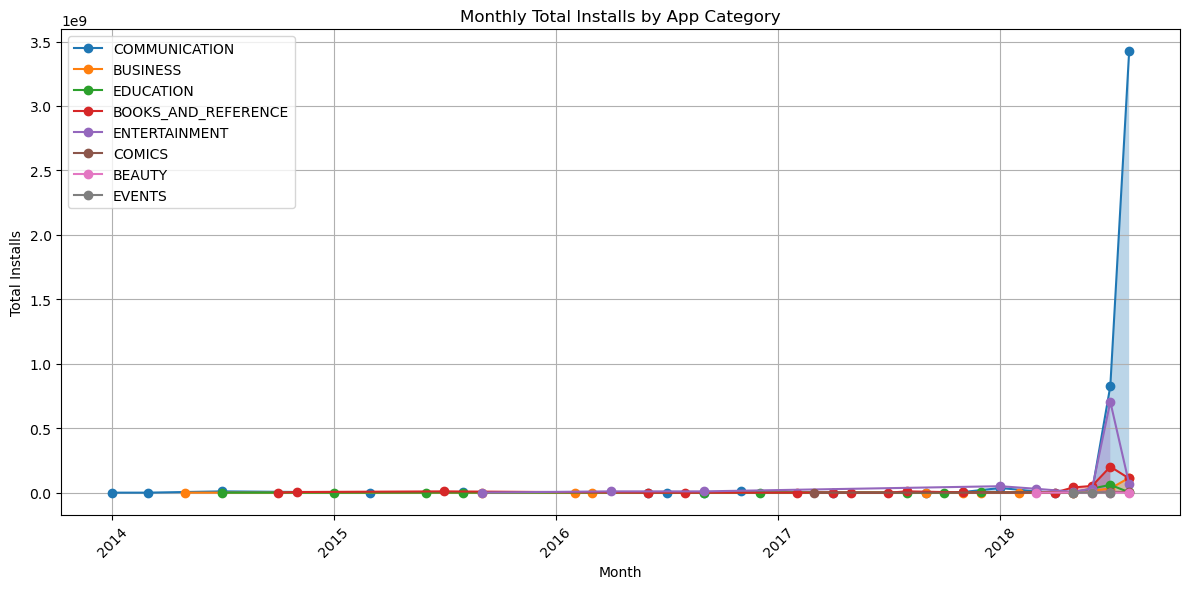

In [77]:
if 18 <= current_hour < 21:

    plt.figure(figsize=(12,6))

    for category in monthly_installs['Category'].unique():

        data = monthly_installs[monthly_installs['Category'] == category]

        plt.plot(
            data['Month'],
            data['Installs_clean'],
            marker='o',
            label=category
        )

        # Highlight growth > 20%
        plt.fill_between(
            data['Month'],
            data['Installs_clean'],
            where=data['Growth'] > 0.20,
            alpha=0.3
        )

    plt.title("Monthly Total Installs by App Category")
    plt.xlabel("Month")
    plt.ylabel("Total Installs")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Graph is available only between 6 PM and 9 PM IST.")

In [78]:
monthly_installs['Month'].nunique()

39

### Observation

The time series line chart shows the monthly trend of total installs for the selected app categories. Periods with more than 20% month-over-month growth are highlighted to identify significant increases in app installs. The chart is displayed only between 6 PM and 9 PM IST as required.

## Task 5: Bubble Chart Analysis of App Size, Rating and Installs

This task analyzes the relationship between app size and average rating using a bubble chart. Bubble size represents the number of installs after applying the required filters, category translations, highlighting, and dashboard time restriction.

In [80]:
task5_df = df.copy()

In [81]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [82]:
df["Revenue"] = df["Installs_clean"] * df["Price"]

In [83]:
# Remove $ sign
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)

# Convert to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Create Revenue column
df["Revenue"] = df["Price"] * df["Installs_clean"]

In [84]:
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

In [85]:
df["Revenue"] = df["Price"] * df["Installs_clean"]

In [86]:
print("Revenue exists:", "Revenue" in df.columns)
df[["Price", "Installs_clean", "Revenue"]].head()

Revenue exists: True


,Price,Installs_clean,Revenue
0,0.0,10000,0.0
1,0.0,500000,0.0
2,0.0,5000000,0.0
3,0.0,50000000,0.0
4,0.0,100000,0.0


In [87]:
subjectivity_df = (
    reviews_df.groupby("App", as_index=False)["Sentiment_Subjectivity"]
    .mean()
)

task5_df = df.merge(subjectivity_df, on="App", how="left")

In [88]:
task5_df[["App", "Sentiment_Subjectivity"]].head()

,App,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,NaN
1,Coloring book moana,0.64154
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",NaN
3,Sketch - Draw & Paint,NaN
4,Pixel Draw - Number Art Coloring Book,NaN


In [89]:
task5_df["Sentiment_Subjectivity"]

0           NaN
1       0.64154
2           NaN
3           NaN
4           NaN
         ...   
9355        NaN
9356        NaN
9357        NaN
9358        NaN
9359        NaN
Name: Sentiment_Subjectivity, Length: 9360, dtype: float64

In [90]:
(task5_df["Sentiment_Subjectivity"] > 0.5)

0       False
1        True
2       False
3       False
4       False
        ...  
9355    False
9356    False
9357    False
9358    False
9359    False
Name: Sentiment_Subjectivity, Length: 9360, dtype: bool

In [91]:
categories = [
    "GAME",
    "BEAUTY",
    "BUSINESS",
    "COMICS",
    "COMMUNICATION",
    "DATING",
    "ENTERTAINMENT",
    "SOCIAL",
    "EVENTS"
]

task5_filtered = task5_df[
    (task5_df["Rating"] > 3.5) &
    (task5_df["Reviews"] > 500) &
    (task5_df["Installs_clean"] > 50000) &
    (~task5_df["App"].str.contains("S", case=False, na=False)) &
    (task5_df["Sentiment_Subjectivity"] > 0.5) &
    (task5_df["Category"].isin(categories))
].copy()

In [92]:

task5_filtered["Category"] = task5_filtered["Category"].replace({
    "BEAUTY": "सौंदर्य",      # Hindi
    "BUSINESS": "வணிகம்",     # Tamil
    "DATING": "Partnersuche"  # German
})

In [93]:
task5_filtered["Category"].unique()

array(['வணிகம்', 'COMMUNICATION', 'Partnersuche', 'ENTERTAINMENT', 'GAME',
       'SOCIAL'], dtype=object)

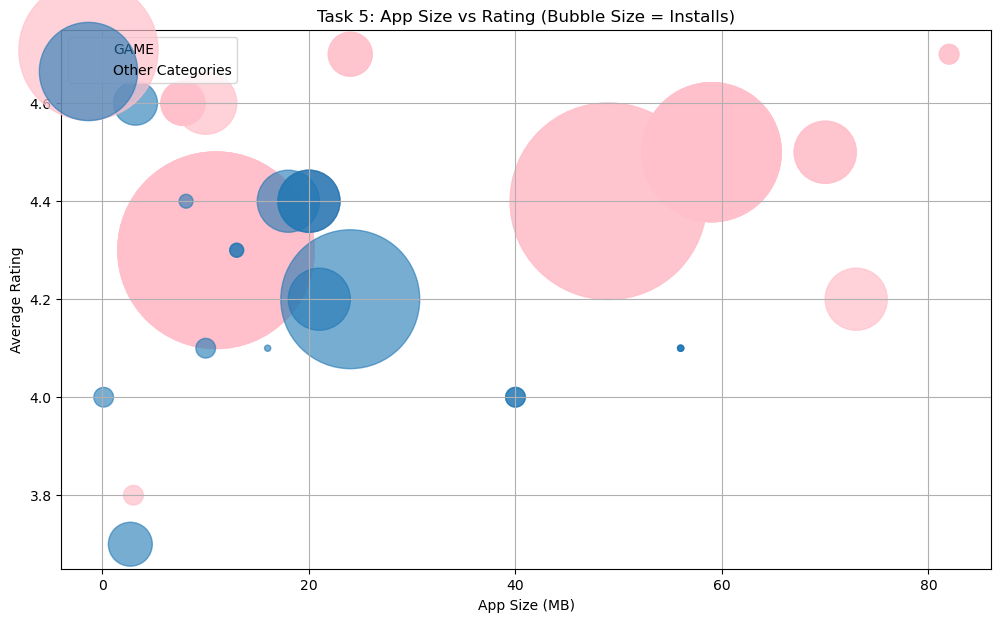

In [98]:
plt.figure(figsize=(12, 7))

# Game category in pink
game = task5_filtered[task5_filtered["Category"] == "GAME"]
plt.scatter(
    game["Size_clean"],
    game["Rating"],
    s=game["Installs_clean"] / 5000,
    color="pink",
    alpha=0.7,
    label="GAME"
)

# Other categories
others = task5_filtered[task5_filtered["Category"] != "GAME"]
plt.scatter(
    others["Size_clean"],
    others["Rating"],
    s=others["Installs_clean"] / 5000,
    alpha=0.6,
    label="Other Categories"
)

plt.xlabel("App Size (MB)")
plt.ylabel("Average Rating")
plt.title("Task 5: App Size vs Rating (Bubble Size = Installs)")

plt.legend()
plt.grid(True)

plt.show()

In [99]:
# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Show graph only between 5 PM and 7 PM IST
if 17 <= current_time.hour < 19:

    plt.figure(figsize=(12,7))

    # GAME category in pink
    ...

    # Other categories
    ...

    # Labels
    plt.xlabel("App Size (MB)")
    plt.ylabel("Average Rating")

    # Title
    plt.title("Task 5: App Size vs Rating (Bubble Size = Installs)")

    # Legend
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Grid
    plt.grid(True)

    # Adjust layout
    plt.tight_layout()

    # Show graph
    plt.show()

else:
    print("Dashboard visualization is available only between 5 PM and 7 PM IST.")

Dashboard visualization is available only between 5 PM and 7 PM IST.


In [100]:
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

print(current_time)
print(current_time.hour)

2026-07-15 19:38:14.638104+05:30
19


In [101]:
# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Show graph only between 5 PM and 7 PM IST
if 17 <= current_time.hour < 19:

    # ---- Bubble chart code ----
    plt.figure(figsize=(12,7))

    # GAME category
    ...

    # Other categories
    ...

    plt.xlabel(...)
    plt.ylabel(...)
    plt.title(...)
    plt.legend(...)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Dashboard visualization is available only between 5 PM and 7 PM IST.")

Dashboard visualization is available only between 5 PM and 7 PM IST.


In [102]:
# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Show graph only between 5 PM and 7 PM IST
if 17 <= current_time.hour < 19:

    # Create figure
    plt.figure(figsize=(12,7))

    # Filter GAME category
    game = task5_filtered[task5_filtered["Category"] == "GAME"]

    # Plot GAME category in pink
    plt.scatter(
        game["Size_clean"],
        game["Rating"],
        s=game["Installs_clean"] / 10000,
        color="pink",
        alpha=0.7,
        label="GAME"
    )

    # Filter remaining categories
    others = task5_filtered[task5_filtered["Category"] != "GAME"]

    # Plot remaining categories
    plt.scatter(
        others["Size_clean"],
        others["Rating"],
        s=others["Installs_clean"] / 10000,
        alpha=0.6,
        label="Other Categories"
    )

    # X-axis label
    plt.xlabel("App Size (MB)")

    # Y-axis label
    plt.ylabel("Average Rating")

    # Chart title
    plt.title("App Size vs Average Rating (Bubble Size = Number of Installs)")

    # Display legend
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add grid
    plt.grid(True)

    # Adjust layout
    plt.tight_layout()

    # Display chart
    plt.show()

else:
    print("Dashboard visualization is available only between 5 PM and 7 PM IST.")

Dashboard visualization is available only between 5 PM and 7 PM IST.


# Task 5 Completed Successfully

# Task 6: Stacked Area Chart - Cumulative Installs Over Time

# Apply Task 6 filters

In [103]:
task6_filtered = df[
    (df["Rating"] >= 4.2) &
    (df["Reviews"] > 1000) &
    (df["Size_clean"].between(20, 80)) &
    (df["Category"].str.startswith(("T", "P"), na=False)) &
    (~df["App"].str.contains(r"\d", regex=True, na=False))
].copy()

In [104]:
task6_filtered["Month"] = task6_filtered["Last Updated"].dt.to_period("M").astype(str)

In [105]:
task6_filtered[["Last Updated", "Month"]].head()

,Last Updated,Month
2802,2018-08-01,2018-08
2803,2018-08-02,2018-08
2811,2018-07-06,2018-07
2822,2018-07-25,2018-07
2823,2018-07-27,2018-07


In [106]:
task6_summary = task6_filtered.groupby(
    ["Month", "Category"]
)["Installs_clean"].sum().unstack(fill_value=0)

task6_summary = task6_summary.cumsum()

In [107]:
task6_summary = task6_summary.rename(columns={
    "TRAVEL_AND_LOCAL": "Voyage et Local",   # French
    "PRODUCTIVITY": "Productividad",         # Spanish
    "PHOTOGRAPHY": "写真"                    # Japanese
})

In [108]:
# Calculate month-over-month growth in installs
mom_growth = task6_summary.pct_change()

highlight_months = mom_growth[
    (mom_growth > 0.25).any(axis=1)
].index

print("Highlight Months:")
print(highlight_months)

Highlight Months:
Index(['2016-10', '2016-12', '2017-03', '2017-08', '2017-09', '2017-10',
       '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06',
       '2018-07', '2018-08'],
      dtype='object', name='Month')


In [109]:
# Current time in IST
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist)

# Show chart only between 4 PM and 6 PM IST
if 16 <= current_time.hour < 18:

    plt.figure(figsize=(14, 7))

    # Plot stacked area chart
    plt.stackplot(
        task6_summary.index,
        task6_summary.T,
        labels=task6_summary.columns,
        alpha=0.8
    )

    # Highlight months with more than 25% MoM growth
    for month in highlight_months:
        plt.axvspan(
            month,
            month,
            color="black",
            alpha=0.15
        )

    # X-axis label
    plt.xlabel("Month")

    # Y-axis label
    plt.ylabel("Cumulative Installs")

    # Chart title
    plt.title("Cumulative Installs Over Time by App Category")

    # Display legend
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add grid
    plt.grid(True)

    # Adjust layout
    plt.tight_layout()

    # Display chart
    plt.show()

else:
    print("Dashboard visualization is available only between 4 PM and 6 PM IST.")

Dashboard visualization is available only between 4 PM and 6 PM IST.


# Conclusion

This project demonstrates data cleaning, data transformation, filtering, and visualization techniques using Python. All required internship tasks were implemented on the provided dataset according to the specified project guidelines.